## The Weather Dataset

### Working on Real Project with Python
----------------------------------------------------------------------


 Here, The Weather Dataset is a time-series data set with per-hour information about the weather conditions at a particular location. It records Temperature, Dew Point Temperature, Relative Humidity, Wind Speed, Visibility, Pressure, and Conditions.

#### This data is available as a CSV file. We are going to analyze this data set using the Pandas DataFrame.
--------------------

## in this project , we will use :

### Pandas Functions Used in This Project

| Function | Purpose |
|----------|---------|
| nunique() | Returns the number of unique values. |
| unique() | Returns all unique values. |
| value_counts() | Counts the occurrences of each unique value. |
| Filtering | Selects rows based on specified conditions. |
| groupby() | Groups data by one or more columns. |
| get_group() | Retrieves a specific group from grouped data. |
| isnull() | Identifies missing (`NaN`) values. |
| notnull() | Identifies non-missing values. |
| rename() | Renames columns or index labels. |
| mean() | Calculates the average value. |
| std() | Calculates the standard deviation. |
| var() | Calculates the variance. |
| str.contains() | Checks whether a string contains a specific pattern. |
| & (AND) | Combines multiple conditions; all must be True. |
|OR  Operator | Combines multiple conditions; at least one must be True. |
| min() | Returns the minimum value. |
| max() | Returns the maximum value. |

In [1]:
## import most important library
import pandas as pd

from ydata_profiling import ProfileReport

c:\Users\3D\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\3D\AppData\Local\Temp\ipykernel_5592\2404647886.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


### frist step : read data from csv file


In [2]:
data=pd.read_csv('Weather_Data.csv')

### second step : use  'ydata_profiling' this library make a summary of the data works very strongly in the form of an html file


In [3]:

# make a Report 
profile = ProfileReport(data, title="Data Profiling Report", explorative=True)

#  save as HTML file
profile.to_file("report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 138.12it/s]


In [4]:
data

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog
...,...,...,...,...,...,...,...,...
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,99.91,Snow


### shape
 it show te total no of rows and no of column of the data frame

In [5]:
data.shape

(8784, 8)

### index
 This attribute provides the index of the dataframe

In [6]:
data.index

RangeIndex(start=0, stop=8784, step=1)

### columns
 it shows the name of each columns

In [7]:
data.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

### dtypes
 it shoew the data-types of each columns

In [8]:
data.dtypes

Date/Time            object
Temp_C              float64
Dew Point Temp_C    float64
Rel Hum_%             int64
Wind Speed_km/h       int64
Visibility_km       float64
Press_kPa           float64
Weather              object
dtype: object

##### Date/Time ------> object :should convert it tow datatime

In [9]:
data['Date/Time'] = pd.to_datetime(data['Date/Time'])


In [10]:
data.dtypes


Date/Time           datetime64[ns]
Temp_C                     float64
Dew Point Temp_C           float64
Rel Hum_%                    int64
Wind Speed_km/h              int64
Visibility_km              float64
Press_kPa                  float64
Weather                     object
dtype: object

### unique
 in a column , it shows all the unique values . it can be applied on a single column only,not on the whole dataframe

In [11]:
data['Weather Condition'].unique()


KeyError: 'Weather Condition'

### nunique ()
 it shows the total no. of unique values in each column . it can be applied on a single column as well as on whole dataframe         


In [ ]:
#data.nunique()
data['Date/Time'].nunique()

8784

## count
 . it show the total no. of non-null in each column.
 . it can be applied on asingle column as well as on whole dataframe

In [ ]:
data.count()

Date/Time           8784
Temp_C              8784
Dew Point Temp_C    8784
Rel Hum_%           8784
Wind Speed_km/h     8784
Visibility_km       8784
Press_kPa           8784
Weather             8784
dtype: int64

## value_counts
in a column,it shows all the unique vaalues with thier count, it can be applied on single column only

In [ ]:
data['Weather'].value_counts()


Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle                

## info()
Provides basic information about the dataframe

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date/Time         8784 non-null   datetime64[ns]
 1   Temp_C            8784 non-null   float64       
 2   Dew Point Temp_C  8784 non-null   float64       
 3   Rel Hum_%         8784 non-null   int64         
 4   Wind Speed_km/h   8784 non-null   int64         
 5   Visibility_km     8784 non-null   float64       
 6   Press_kPa         8784 non-null   float64       
 7   Weather           8784 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 549.1+ KB


### Q ) 1 - Find all the unique 'Wind Speed' values in the data

In [ ]:
data.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [ ]:
data.head(2)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog


In [ ]:
data.nunique()

Date/Time           8784
Temp_C               533
Dew Point Temp_C     489
Rel Hum_%             83
Wind Speed_km/h       34
Visibility_km         24
Press_kPa            518
Weather               50
dtype: int64

In [ ]:
data['Wind Speed_km/h'].nunique()


34

In [ ]:
 data['Wind Speed_km/h'].unique() #Anser

array([ 4,  7,  6,  9, 15, 13, 20, 22, 19, 24, 30, 35, 39, 32, 33, 26, 44,
       43, 48, 37, 28, 17, 11,  0, 83, 70, 57, 46, 41, 52, 50, 63, 54,  2])

In [ ]:
data['Wind Speed_km/h'].mean()


np.float64(14.94546903460838)

### Q ) 2-Find the number of times When the 'Weather is exacly Clear'.

In [ ]:
data.head(5)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [ ]:
data.Weather.value_counts()
data.Weather.value_counts()

Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle                

In [ ]:
data.Weather=='Clear'

0       False
1       False
2       False
3       False
4       False
        ...  
8779    False
8780    False
8781    False
8782    False
8783    False
Name: Weather, Length: 8784, dtype: bool

In [ ]:

data[data.Weather=='Clear']

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
67,2012-01-03 19:00:00,-16.9,-24.8,50,24,25.0,101.74,Clear
114,2012-01-05 18:00:00,-7.1,-14.4,56,11,25.0,100.71,Clear
115,2012-01-05 19:00:00,-9.2,-15.4,61,7,25.0,100.80,Clear
116,2012-01-05 20:00:00,-9.8,-15.7,62,9,25.0,100.83,Clear
117,2012-01-05 21:00:00,-9.0,-14.8,63,13,25.0,100.83,Clear
...,...,...,...,...,...,...,...,...
8646,2012-12-26 06:00:00,-13.4,-14.8,89,4,25.0,102.47,Clear
8698,2012-12-28 10:00:00,-6.1,-8.6,82,19,24.1,101.27,Clear
8713,2012-12-29 01:00:00,-11.9,-13.6,87,11,25.0,101.31,Clear
8714,2012-12-29 02:00:00,-11.8,-13.1,90,13,25.0,101.33,Clear


In [ ]:
data.groupby('Weather').get_group('Clear')

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
67,2012-01-03 19:00:00,-16.9,-24.8,50,24,25.0,101.74,Clear
114,2012-01-05 18:00:00,-7.1,-14.4,56,11,25.0,100.71,Clear
115,2012-01-05 19:00:00,-9.2,-15.4,61,7,25.0,100.80,Clear
116,2012-01-05 20:00:00,-9.8,-15.7,62,9,25.0,100.83,Clear
117,2012-01-05 21:00:00,-9.0,-14.8,63,13,25.0,100.83,Clear
...,...,...,...,...,...,...,...,...
8646,2012-12-26 06:00:00,-13.4,-14.8,89,4,25.0,102.47,Clear
8698,2012-12-28 10:00:00,-6.1,-8.6,82,19,24.1,101.27,Clear
8713,2012-12-29 01:00:00,-11.9,-13.6,87,11,25.0,101.31,Clear
8714,2012-12-29 02:00:00,-11.8,-13.1,90,13,25.0,101.33,Clear


### Q ) 3-Find the number of times when the 'Wind Speed was exacly 4km/h'.

In [ ]:
data.head(2)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog


In [ ]:
data['Wind Speed_km/h'].value_counts()


Wind Speed_km/h
9     830
11    791
13    735
15    719
7     677
17    666
19    616
6     609
20    496
4     474
22    439
24    374
0     309
26    242
28    205
30    161
32    139
33     85
35     53
37     45
39     24
41     22
44     14
43     13
48     13
46     11
52      7
57      5
50      4
2       2
70      1
83      1
63      1
54      1
Name: count, dtype: int64

In [ ]:
data[data['Wind Speed_km/h']==4]
data[data['Wind Speed_km/h']==4]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
96,2012-01-05 00:00:00,-8.8,-11.7,79,4,9.7,100.32,Snow
101,2012-01-05 05:00:00,-7.0,-9.5,82,4,4.0,100.19,Snow
146,2012-01-07 02:00:00,-8.1,-11.1,79,4,19.3,100.15,Cloudy
...,...,...,...,...,...,...,...,...
8768,2012-12-31 08:00:00,-8.6,-10.3,87,4,3.2,101.14,Snow Showers
8769,2012-12-31 09:00:00,-8.1,-9.6,89,4,2.4,101.09,Snow
8770,2012-12-31 10:00:00,-7.4,-8.9,89,4,6.4,101.05,"Snow,Fog"
8772,2012-12-31 12:00:00,-5.8,-7.5,88,4,12.9,100.78,Snow


### Q ) 4-Find out all the Null values in the data

In [ ]:
data.isnull().sum()

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

In [ ]:
data.notnull()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...
8779,True,True,True,True,True,True,True,True
8780,True,True,True,True,True,True,True,True
8781,True,True,True,True,True,True,True,True
8782,True,True,True,True,True,True,True,True


### Q ) 5-Rename the column name 'Weather' of the dataframe to 'Weather Condition'.

In [ ]:
data.head(2)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog


In [ ]:
data=data.rename(columns={'Weather':'Weather Condition'})

### Q ) 6-What is the mean 'Visibility'.

In [ ]:
data.Visibility_km.mean()

np.float64(27.664446721311474)

### Q ) 7-What is the standard Deviation of 'Pressure' in this data ?

In [ ]:
data.Press_kPa.std()

np.float64(0.8440047459486483)

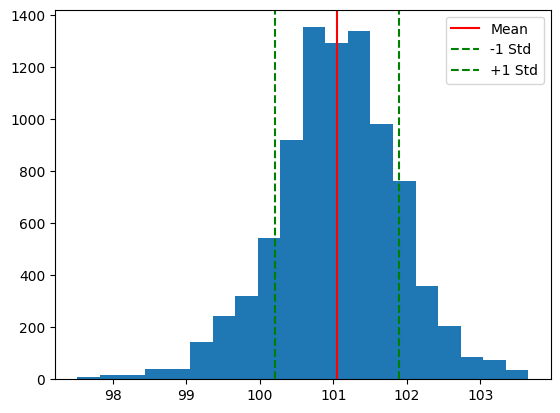

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
mean = data['Press_kPa'].mean()
std =data['Press_kPa'].std()

plt.hist(data['Press_kPa'], bins=20)

# المتوسط
plt.axvline(mean, color='red', label='Mean')

# ±1 Standard Deviation
plt.axvline(mean - std, color='green', linestyle='--', label='-1 Std')
plt.axvline(mean + std, color='green', linestyle='--', label='+1 Std')

plt.legend()
plt.show()

### Q ) 8-What is the Variance of 'Relative Humidity' in this data ?

In [ ]:
data['Rel Hum_%'].var()

np.float64(286.24855019850196)

### Q ) 9-Find all instances when 'Snow' was recorded.

In [ ]:
data['Weather Condition'].value_counts()


Weather Condition
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle      

In [ ]:
data[data['Weather Condition']=='Snow']

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather Condition
55,2012-01-03 07:00:00,-14.0,-19.5,63,19,25.0,100.95,Snow
84,2012-01-04 12:00:00,-13.7,-21.7,51,11,24.1,101.25,Snow
86,2012-01-04 14:00:00,-11.3,-19.0,53,7,19.3,100.97,Snow
87,2012-01-04 15:00:00,-10.2,-16.3,61,11,9.7,100.89,Snow
88,2012-01-04 16:00:00,-9.4,-15.5,61,13,19.3,100.79,Snow
...,...,...,...,...,...,...,...,...
8779,2012-12-31 19:00:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,2012-12-31 20:00:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,2012-12-31 21:00:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,2012-12-31 22:00:00,-0.2,-1.8,89,28,9.7,99.91,Snow


In [ ]:
data[data['Weather Condition'].str.contains('Snow')]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather Condition
41,2012-01-02 17:00:00,-2.1,-9.5,57,22,25.0,99.66,Snow Showers
44,2012-01-02 20:00:00,-5.6,-13.4,54,24,25.0,100.07,Snow Showers
45,2012-01-02 21:00:00,-5.8,-12.8,58,26,25.0,100.15,Snow Showers
47,2012-01-02 23:00:00,-7.4,-14.1,59,17,19.3,100.27,Snow Showers
48,2012-01-03 00:00:00,-9.0,-16.0,57,28,25.0,100.35,Snow Showers
...,...,...,...,...,...,...,...,...
8779,2012-12-31 19:00:00,0.1,-2.7,81,30,9.7,100.13,Snow
8780,2012-12-31 20:00:00,0.2,-2.4,83,24,9.7,100.03,Snow
8781,2012-12-31 21:00:00,-0.5,-1.5,93,28,4.8,99.95,Snow
8782,2012-12-31 22:00:00,-0.2,-1.8,89,28,9.7,99.91,Snow


### Q ) 10-Find all instances when 'Wind Speed is above 24' and 'visibility is 25'.

In [ ]:
data.head(2)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather Condition
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog


In [ ]:
data[(data['Wind Speed_km/h']>24) & (data['Visibility_km']==25)]
data[(data['Wind Speed_km/h']>24)&(data['Visibility_km']==25)]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
23,2012-01-01 23:00:00,5.3,2.0,79,30,25.0,99.31,Cloudy
24,2012-01-02 00:00:00,5.2,1.5,77,35,25.0,99.26,Rain Showers
25,2012-01-02 01:00:00,4.6,0.0,72,39,25.0,99.26,Cloudy
26,2012-01-02 02:00:00,3.9,-0.9,71,32,25.0,99.26,Mostly Cloudy
27,2012-01-02 03:00:00,3.7,-1.5,69,33,25.0,99.30,Mostly Cloudy
...,...,...,...,...,...,...,...,...
8705,2012-12-28 17:00:00,-8.6,-12.0,76,26,25.0,101.34,Mainly Clear
8753,2012-12-30 17:00:00,-12.1,-15.8,74,28,25.0,101.26,Mainly Clear
8755,2012-12-30 19:00:00,-13.4,-16.5,77,26,25.0,101.47,Mainly Clear
8759,2012-12-30 23:00:00,-12.1,-15.1,78,28,25.0,101.52,Mostly Cloudy


### Q ) 11- What is the Mean value of each columns against each 'Weather Condition'

In [ ]:
data.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [ ]:
data.groupby('Weather').agg('max','min')

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
Weather,,,,,,
Clear,32.8,20.4,99,33,48.3,103.63
Cloudy,30.5,22.6,99,54,48.3,103.65
Drizzle,18.8,17.7,96,30,25.0,101.56
"Drizzle,Fog",19.9,19.1,100,28,9.7,102.07
"Drizzle,Ice Pellets,Fog",0.4,-0.7,92,20,4.0,100.79
"Drizzle,Snow",1.2,0.2,95,19,11.3,101.15
"Drizzle,Snow,Fog",1.1,0.6,98,32,9.7,100.15
Fog,20.8,19.6,100,22,9.7,103.04
Freezing Drizzle,-2.3,-3.3,93,26,12.9,101.02


### Q ) 12- What is the minmum & maximum value or each column against each 'Weather Condition'?

In [ ]:
data.head(2)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog


In [ ]:
data.groupby('Weather').agg(['min','max'])

Date/Time  \
                                                        min   
Weather                                                       
Clear                                   2012-01-03 19:00:00   
Cloudy                                  2012-01-01 17:00:00   
Drizzle                                 2012-01-23 21:00:00   
Drizzle,Fog                             2012-01-23 20:00:00   
Drizzle,Ice Pellets,Fog                 2012-12-17 09:00:00   
Drizzle,Snow                            2012-12-17 15:00:00   
Drizzle,Snow,Fog                        2012-12-18 21:00:00   
Fog                                     2012-01-01 00:00:00   
Freezing Drizzle                        2012-01-07 11:00:00   
Freezing Drizzle,Fog                    2012-01-01 02:00:00   
Freezing Drizzle,Haze                   2012-02-01 11:00:00   
Freezing Drizzle,Snow                   2012-01-13 03:00:00   
Freezing Fog                            2012-01-22 06:00:00   
Freezing Rain                           2012-01-07 10:00:00   
Freezing Rain,Fog                       2012-01-07 09:00:00   
Freezing Rain,Haze                      2012-02-01 14:00:00   
Freezing Rain,Ice Pellets,Fog           2012-12-17 03:00:00   
Freezing Rain,Snow Grains               2012-01-13 09:00:00   
Haze                                    2012-01-22 12:00:00   
Mainly Clear                            2012-01-02 12:00:00   
Moderate Rain,Fog                       2012-12-10 08:00:00   
Moderate Snow                           2012-01-12 15:00:00   
Moderate Snow,Blowing Snow              2012-12-27 10:00:00   
Mostly Cloudy                           2012-01-01 16:00:00   
Rain                                    2012-01-01 18:00:00   
Rain Showers                            2012-01-01 22:00:00   
Rain Showers,Fog                        2012-10-20 03:00:00   
Rain Showers,Snow Showers               2012-11-04 08:00:00   
Rain,Fog                                2012-01-23 18:00:00   
Rain,Haze                               2012-03-13 07:00:00   
Rain,Ice Pellets                        2012-12-18 05:00:00   
Rain,Snow                               2012-01-10 05:00:00   
Rain,Snow Grains                        2012-12-21 00:00:00   
Rain,Snow,Fog                           2012-12-08 21:00:00   
Rain,Snow,Ice Pellets                   2012-12-21 01:00:00   
Snow                                    2012-01-03 07:00:00   
Snow Pellets                            2012-11-24 15:00:00   
Snow Showers                            2012-01-02 17:00:00   
Snow Showers,Fog                        2012-12-26 09:00:00   
Snow,Blowing Snow                       2012-01-13 21:00:00   
Snow,Fog                                2012-02-10 23:00:00   
Snow,Haze                               2012-02-01 17:00:00   
Snow,Ice Pellets                        2012-03-03 04:00:00   
Thunderstorms                           2012-07-04 16:00:00   
Thunderstorms,Heavy Rain Showers        2012-05-29 06:00:00   
Thunderstorms,Moderate Rain Showers,Fog 2012-07-17 06:00:00   
Thunderstorms,Rain                      2012-05-25 20:00:00   
Thunderstorms,Rain Showers              2012-05-29 04:00:00   
Thunderstorms,Rain Showers,Fog          2012-06-29 03:00:00   
Thunderstorms,Rain,Fog                  2012-07-17 05:00:00   

                                                            Temp_C        \
                                                        max    min   max   
Weather                                                                    
Clear                                   2012-12-30 20:00:00  -23.3  32.8   
Cloudy                                  2012-12-31 06:00:00  -21.4  30.5   
Drizzle                                 2012-12-22 01:00:00    1.1  18.8   
Drizzle,Fog                             2012-12-19 10:00:00    0.0  19.9   
Drizzle,Ice Pellets,Fog                 2012-12-17 09:00:00    0.4   0.4   
Drizzle,Snow                            2012-12-19 18:00:00    0.9   1.2   
Drizzle,Snow,Fog          

### Q ) 13-Show all the Records where Weather Condition is Fog

In [ ]:
data[data['Weather Condition']=='Fog']

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather Condition
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog
5,2012-01-01 05:00:00,-1.4,-3.3,87,9,6.4,101.27,Fog
6,2012-01-01 06:00:00,-1.5,-3.1,89,7,6.4,101.29,Fog
...,...,...,...,...,...,...,...,...
8716,2012-12-29 04:00:00,-16.0,-17.2,90,6,9.7,101.25,Fog
8717,2012-12-29 05:00:00,-14.8,-15.9,91,4,6.4,101.25,Fog
8718,2012-12-29 06:00:00,-13.8,-15.3,88,4,9.7,101.25,Fog
8719,2012-12-29 07:00:00,-14.8,-16.4,88,7,8.0,101.22,Fog


### Q ) 14-Find all instances when 'Weather is Clear' or 'Visibility is above 40'.

In [ ]:
data[(data['Weather Condition']=='Clear') | (data['Visibility_km']>40)].head(50)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather Condition
67,2012-01-03 19:00:00,-16.9,-24.8,50,24,25.0,101.74,Clear
106,2012-01-05 10:00:00,-6.0,-10.0,73,17,48.3,100.45,Mainly Clear
107,2012-01-05 11:00:00,-5.6,-10.2,70,22,48.3,100.41,Mainly Clear
108,2012-01-05 12:00:00,-4.7,-9.6,69,20,48.3,100.38,Mainly Clear
109,2012-01-05 13:00:00,-4.4,-9.7,66,26,48.3,100.40,Mainly Clear
110,2012-01-05 14:00:00,-5.1,-10.7,65,22,48.3,100.46,Mainly Clear
111,2012-01-05 15:00:00,-4.3,-12.0,55,26,48.3,100.52,Mainly Clear
114,2012-01-05 18:00:00,-7.1,-14.4,56,11,25.0,100.71,Clear
115,2012-01-05 19:00:00,-9.2,-15.4,61,7,25.0,100.80,Clear
116,2012-01-05 20:00:00,-9.8,-15.7,62,9,25.0,100.83,Clear


### Q ) 15-Find all instances when :
A. 'Weather is clear' and 'Relative Humidity is greater than 50'.

or
B.'Visibility is above 40'.

In [ ]:
data.head(2)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather Condition
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog


In [ ]:

data[((data['Weather']=='Clear')&(data['Rel Hum_%']>50)) | (data['Visibility_km']>40)]

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
106,2012-01-05 10:00:00,-6.0,-10.0,73,17,48.3,100.45,Mainly Clear
107,2012-01-05 11:00:00,-5.6,-10.2,70,22,48.3,100.41,Mainly Clear
108,2012-01-05 12:00:00,-4.7,-9.6,69,20,48.3,100.38,Mainly Clear
109,2012-01-05 13:00:00,-4.4,-9.7,66,26,48.3,100.40,Mainly Clear
110,2012-01-05 14:00:00,-5.1,-10.7,65,22,48.3,100.46,Mainly Clear
...,...,...,...,...,...,...,...,...
8749,2012-12-30 13:00:00,-12.4,-16.2,73,37,48.3,100.92,Mostly Cloudy
8750,2012-12-30 14:00:00,-11.8,-16.1,70,37,48.3,100.96,Mainly Clear
8751,2012-12-30 15:00:00,-11.3,-15.6,70,32,48.3,101.05,Mainly Clear
8752,2012-12-30 16:00:00,-11.4,-15.5,72,26,48.3,101.15,Mainly Clear


### Why did we split the Date/Time column?
---------

 - Easier to analyze data by year, month, day, and hour.
 - Compare weather across months and weekdays.
 - Identify time-based patterns and trends.
 - Improve data analysis with feature engineering.

In [ ]:
data['Year']=data['Date/Time'].dt.year
data['month']=data['Date/Time'].dt.month
data['month_name']=data['Date/Time'].dt.month_name()
data['Day']=data['Date/Time'].dt.day
data['houre']=data['Date/Time'].dt.hour
data['Weakday']=data['Date/Time'].dt.day_name()
data.head(2)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Year,month,month_name,Day,houre,Weakday,Season
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog,2012,1,January,1,0,Sunday,Winter
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog,2012,1,January,1,1,Sunday,Winter


### Why did we create the Season column?
-------------------

 - Group months into four seasons.
 - Compare weather conditions by season.
 - Identify seasonal trends more easily.
 - Simplify visualization and reporting.

In [ ]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Autumn'
data['Season']=data['month'].apply(get_season)
data.head(2)


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Year,month,month_name,Day,houre,Weakday,Season
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog,2012,1,January,1,0,Sunday,Winter
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog,2012,1,January,1,1,Sunday,Winter


In [ ]:
data.groupby('Season').agg(['max','min'])

Date/Time            Temp_C       Dew Point Temp_C        \
                       max        min    max   min              max   min   
Season                                                                      
Autumn 2012-11-30 23:00:00 2012-09-01   28.4 -13.6             20.2 -17.3   
Spring 2012-05-31 23:00:00 2012-03-01   31.2 -16.2             19.0 -22.6   
Summer 2012-08-31 23:00:00 2012-06-01   33.0   9.5             24.4   1.0   
Winter 2012-12-31 23:00:00 2012-01-01   11.9 -23.3              9.7 -28.5   

       Rel Hum_%     Wind Speed_km/h      ... month     month_name            \
             max min             max min  ...   max min        max       min   
Season                                    ...                                  
Autumn       100  29              54   0  ...    11   9  September  November   
Spring       100  18              63   0  ...     5   3        May     April   
Summer        99  24              44   0  ...     8   6       June    August   
Winter       100  37              83   0  ...    12   1    January  December   

       Day     houre        Weakday          
       max min   max min        max     min  
Season                                       
Autumn  31   1    23   0  Wednesday  Friday  
Spring  31   1    23   0  Wednesday  Friday  
Summer  31   1    23   0  Wednesday  Friday  
Winter  31   1    23   0  Wednesday  Friday  

[4 rows x 28 columns]

# Real Question

1-Which season has the highest average temperature?

In [ ]:
data.groupby('Season')['Temp_C'].mean().sort_values()

Season
Winter    -4.983929
Spring     8.808786
Autumn     9.473397
Summer    21.751857
Name: Temp_C, dtype: float64

2- higher and lower and the average temperature in each season

In [ ]:
data.groupby('Season')['Temp_C'].agg(['min','max','mean'])

,min,max,mean
Season,,,
Autumn,-13.6,28.4,9.473397
Spring,-16.2,31.2,8.808786
Summer,9.5,33.0,21.751857
Winter,-23.3,11.9,-4.983929


3-Average Relative Humidity in each season

In [ ]:
data.groupby('Season')['Rel Hum_%'].mean()

Season
Autumn    72.331502
Spring    60.976449
Summer    63.566123
Winter    72.966117
Name: Rel Hum_%, dtype: float64

4-higher and lower Atmospheric Pressure in each season


In [ ]:
data.groupby('Season')['Press_kPa'].agg(['max','min'])

,max,min
Season,,
Autumn,103.65,98.89
Spring,103.12,98.47
Summer,102.40,99.39
Winter,103.27,97.52


5-higher and lower and the average Wind speed in each season

In [ ]:
data.groupby('Season')['Wind Speed_km/h'].agg(['min','max','mean'])

,min,max,mean
Season,,,
Autumn,0,54,14.529762
Spring,0,63,14.883605
Summer,0,44,13.487319
Winter,0,83,16.897894


6-Temperture per month

In [ ]:
months = [
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

monthly = data.groupby('month_name')['Temp_C'].agg(['min','max','mean']).reindex(months)
monthly

,min,max,mean
month_name,,,
January,-23.3,5.3,-7.371505
February,-16.9,6.1,-4.225000
March,-16.2,25.5,3.121237
April,-3.0,27.8,7.009306
May,4.6,31.2,16.237769
June,9.5,33.0,20.134028
July,12.4,33.0,22.790054
August,10.5,32.8,22.279301
September,4.9,28.4,16.484444


7-Temperture per Weakday

In [ ]:
data.groupby('Weakday')['Temp_C'].mean()


Weakday
Friday       9.353766
Monday       8.853931
Saturday     8.388622
Sunday       7.854560
Thursday     9.456731
Tuesday      8.889583
Wednesday    8.806891
Name: Temp_C, dtype: float64

8-Temperture per houer We need to now what is hosure ha highest temperture

In [ ]:
hourly = data.groupby('houre')['Temp_C'].agg(['min','max','mean'])
hourly

,min,max,mean
houre,,,
0,-21.2,26.5,7.568579
1,-21.1,25.9,7.090437
2,-21.4,25.1,6.656011
3,-20.7,24.6,6.291803
4,-21.0,24.3,5.969126
5,-21.3,24.1,5.717760
6,-23.2,24.6,6.033060
7,-22.8,25.9,6.572951
8,-23.3,26.5,7.378142


9-Relative Humidity (max,min,mean) per month

In [ ]:
data.groupby('month')['Rel Hum_%'].agg(['min','max','mean'])

,min,max,mean
month,,,
1,42,93,68.383065
2,37,94,68.956897
3,18,100,64.862903
4,21,94,56.150000
5,18,95,61.760753
6,24,90,60.643056
7,26,98,62.017473
8,35,99,67.943548
9,29,100,71.165278


10-Relative Humidity (max,min,mean) per Season

In [ ]:
data.groupby('Season')['Rel Hum_%'].agg(['min','max','mean'])

,min,max,mean
Season,,,
Autumn,29,100,72.331502
Spring,18,100,60.976449
Summer,24,99,63.566123
Winter,37,100,72.966117


11-Wnidow Speed (max,min,mean) per month

In [ ]:
data.groupby('month')['Wind Speed_km/h'].agg(['min','max','mean'])


,min,max,mean
month,,,
1,0,83,18.108871
2,0,41,14.837644
3,0,63,14.514785
4,0,52,17.369444
5,0,35,12.846774
6,0,37,14.681944
7,0,35,11.887097
8,0,44,13.931452
9,0,44,14.108333


11-Wnidow Speed (max,min,mean) per Season

In [ ]:
data.groupby('Season')['Wind Speed_km/h'].agg(['min','max','mean'])

,min,max,mean
Season,,,
Autumn,0,54,14.529762
Spring,0,63,14.883605
Summer,0,44,13.487319
Winter,0,83,16.897894


12-visibilty (max,min,mean) per month

In [ ]:
data.groupby('month')['Wind Speed_km/h'].agg(['min','max','mean'])

,min,max,mean
month,,,
1,0,83,18.108871
2,0,41,14.837644
3,0,63,14.514785
4,0,52,17.369444
5,0,35,12.846774
6,0,37,14.681944
7,0,35,11.887097
8,0,44,13.931452
9,0,44,14.108333


14-Press_kPa (max,min,mean) per month

In [ ]:
data.groupby('month')['Press_kPa'].agg(['min','max','mean'])

,min,max,mean
month,,,
1,97.99,103.09,101.005349
2,97.97,102.72,101.142414
3,98.67,103.12,101.335255
4,98.47,102.44,100.716833
5,99.46,101.95,101.057164
6,99.39,102.40,100.784222
7,99.65,101.75,100.828333
8,100.06,102.10,100.927097
9,98.89,102.06,101.087903


15-Press_kPa (max,min,mean) per Season

In [ ]:
data.groupby('Season')['Press_kPa'].agg(['min','max','mean'])

,min,max,mean
Season,,,
Autumn,98.89,103.65,101.215128
Spring,98.47,103.12,101.039891
Summer,99.39,102.40,100.847228
Winter,97.52,103.27,101.106621


In [ ]:
data.nlargest(3,'Wind Speed_km/h')

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Year,month,month_name,Day,houre,Weakday,Season
409,2012-01-18 01:00:00,3.7,-2.1,66,83,25.0,98.36,Mostly Cloudy,2012,1,January,18,1,Wednesday,Winter
410,2012-01-18 02:00:00,0.5,-4.0,72,70,25.0,98.62,Mostly Cloudy,2012,1,January,18,2,Wednesday,Winter
1504,2012-03-03 16:00:00,5.0,-5.0,48,63,48.3,98.67,Mainly Clear,2012,3,March,3,16,Saturday,Spring


In [ ]:
data['Weather'].value_counts(normalize=True)*100

Weather
Mainly Clear                               23.975410
Mostly Cloudy                              23.554189
Cloudy                                     19.672131
Clear                                      15.095628
Snow                                        4.439891
Rain                                        3.483607
Rain Showers                                2.140255
Fog                                         1.707650
Rain,Fog                                    1.320583
Drizzle,Fog                                 0.910747
Snow Showers                                0.683060
Drizzle                                     0.466758
Snow,Fog                                    0.421220
Snow,Blowing Snow                           0.216302
Rain,Snow                                   0.204918
Thunderstorms,Rain Showers                  0.182149
Haze                                        0.182149
Drizzle,Snow,Fog                            0.170765
Freezing Rain                         